# Motion Descriptors

pybvh 0.8.0 adds a layer of **theory-neutral motion descriptors** — geometric
and dynamic properties measured straight from the motion, framework-agnostic
(NumPy in, NumPy out). They live in three modules:

- **`pybvh.geometry`** — positions in R³: distances, angles, areas, bounding
  volumes, centre of mass, and trajectory curvature / torsion / path.
- **`pybvh.analysis`** — dynamics: jerk, smoothness, kinetic energy, gait.
- **`pybvh.rotations`** — SE(3) rigid-transform math (twists, screw
  interpolation, geodesic distance).

Most descriptors also have a thin `Bvh` method for the common single-joint
case. This tutorial walks through them on a real clip and sanity-checks a
couple against closed-form answers — because a number can be right yet
wrong-shaped, and a picture catches convention bugs instantly.

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)
import matplotlib.pyplot as plt
from pathlib import Path

import pybvh
from pybvh import geometry, analysis, rotations

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
bvh = pybvh.read_bvh_file(REPO_ROOT / "bvh_data" / "bvh_test1.bvh")
t = np.arange(bvh.frame_count) * bvh.frame_time
print(bvh)

24 joints, 75 frames at 30.0 fps (frame_time=0.033333s, from bvh_test1.bvh)


## 1. Trajectory descriptors

How a single joint moves through space: how far it travels (`path_length`),
how directly (`directness`, where 1 is a perfectly straight line), and how
sharply it turns (`curvature`). Relational and trajectory methods index in
**node space**, so end sites (fingertips, head top, toe tips) are
first-class — pass any joint or end-site name.

RightHand: path length = 169.74, directness = 0.011


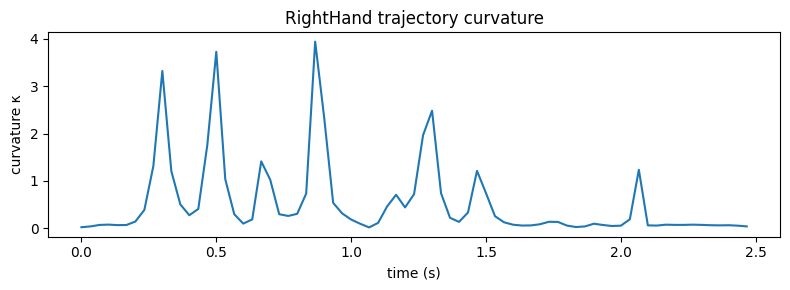

In [2]:
joint = "RightHand"
print(f"{joint}: path length = {bvh.path_length(joint):.2f}, "
      f"directness = {bvh.directness(joint):.3f}")

kappa = bvh.curvature(joint)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, kappa)
ax.set(xlabel="time (s)", ylabel="curvature κ", title=f"{joint} trajectory curvature")
plt.tight_layout()

### Sanity check: a hand tracing a circle

A trajectory we *know* — a circle of radius `r` traced at constant speed —
must have curvature exactly `1/r` everywhere and directness ≈ 0 (it returns
to its start). This pins the convention against a closed-form answer.

radius r = 2.0  ->  1/r = 0.5000
measured curvature (interior mean) = 0.5000
directness = 0.0014   (≈ 0, closed loop)


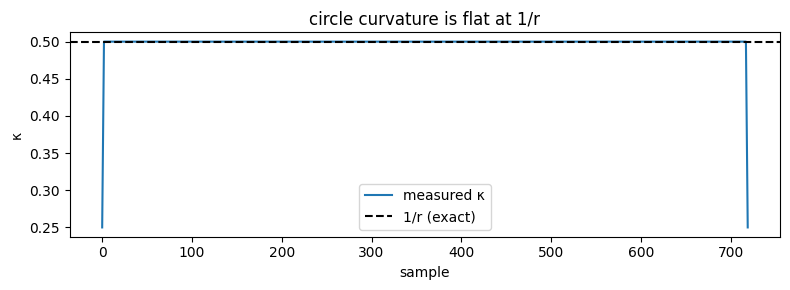

In [3]:
n, r = 720, 2.0
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
circle = np.stack([r * np.cos(theta), r * np.sin(theta), np.zeros(n)], axis=1)
dt = theta[1] - theta[0]

kappa_circle = geometry.curvature(circle, dt)
print(f"radius r = {r}  ->  1/r = {1 / r:.4f}")
print(f"measured curvature (interior mean) = {kappa_circle[5:-5].mean():.4f}")
print(f"directness = {geometry.directness(circle):.4f}   (≈ 0, closed loop)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(kappa_circle, label="measured κ")
ax.axhline(1 / r, color="k", ls="--", label="1/r (exact)")
ax.set(xlabel="sample", ylabel="κ", title="circle curvature is flat at 1/r")
ax.legend()
plt.tight_layout()

assert np.allclose(kappa_circle[5:-5], 1 / r, rtol=1e-2)

## 2. Smoothness and jerk

Smoothness metrics summarize a joint's *speed profile* in one number. SPARC
(spectral arc length) and log dimensionless jerk (LDLJ) are the standards —
closer to 0 is smoother; the number of speed peaks counts sub-movements.
Jerk, the third derivative of position, is the raw signal they build on.

RightHand SPARC      = -2.255
RightHand LDLJ       = -12.249
RightHand # of peaks = 9


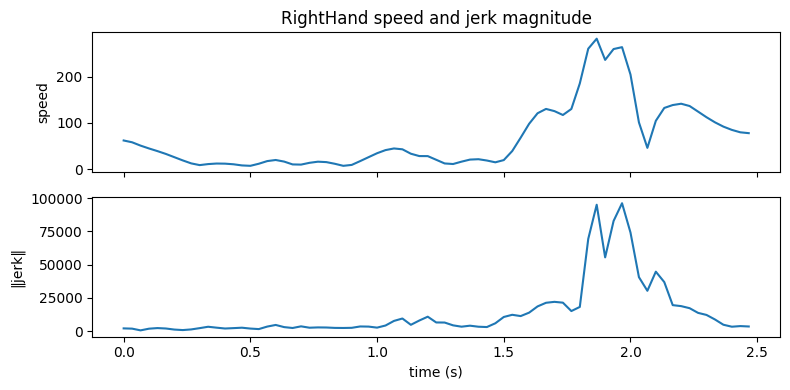

In [4]:
hand = "RightHand"
node = bvh.index(hand, space="node")
print(f"{hand} SPARC      = {bvh.smoothness(hand, metric='sparc'):.3f}")
print(f"{hand} LDLJ       = {bvh.smoothness(hand, metric='log_dimensionless_jerk'):.3f}")
print(f"{hand} # of peaks = {bvh.smoothness(hand, metric='number_of_peaks')}")

speed = np.linalg.norm(bvh.node_velocities()[:, node, :], axis=-1)
jerk = np.linalg.norm(bvh.node_jerk()[:, node, :], axis=-1)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
a1.plot(t, speed); a1.set(ylabel="speed")
a2.plot(t, jerk); a2.set(ylabel="‖jerk‖", xlabel="time (s)")
a1.set_title(f"{hand} speed and jerk magnitude")
plt.tight_layout()

## 3. Whole-body shape: bounding volume and centre of mass

Per-frame descriptors of the whole pose: its bounding box (and sphere), the
uniform centre of mass, and verticality (height ÷ width) — a posture proxy
that rises when the figure stands tall and drops when it crouches.

bounding-box volume: 13925.2 -> 61367.4
centre of mass drifts from [-1.2931 -9.8838 38.0437] to [ -1.0937 -13.4436  37.7656]


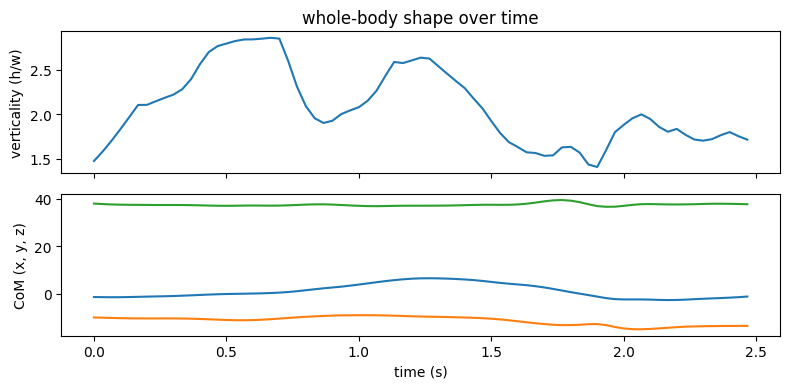

In [5]:
box = bvh.bounding_box()
com = bvh.center_of_mass()
vert = bvh.verticality()
print(f"bounding-box volume: {box.volume.min():.1f} -> {box.volume.max():.1f}")
print(f"centre of mass drifts from {com[0]} to {com[-1]}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
a1.plot(t, vert); a1.set(ylabel="verticality (h/w)")
a2.plot(t, com); a2.set(ylabel="CoM (x, y, z)", xlabel="time (s)")
a1.set_title("whole-body shape over time")
plt.tight_layout()

## 4. Gait

From foot contacts plus the root's ground-plane path, pybvh estimates cadence
(steps per second), stride length, and walking pace. The foot joints are
auto-detected from skeleton topology (pass `foot_joints=[...]` to override).

In [6]:
print("detected feet:", analysis.auto_detect_foot_joints(bvh))
print(f"cadence       = {bvh.cadence():.3f} steps/s")
print(f"stride length = {bvh.stride_length():.3f}")
print(f"walking pace  = {bvh.walking_pace():.3f} units/s")

detected feet: ['LeftToeBase', 'RightToeBase']
cadence       = 1.216 steps/s
stride length = 14.364
walking pace  = 8.735 units/s


## 5. SE(3) rigid-transform math

`pybvh.rotations` now handles rigid transforms. `relative_transform` gives the
pose of one body segment in another's local frame; `se3_log` turns a 4×4
transform into its twist coordinates `[ω, v]`; and `rotation_geodesic_distance`
measures the shortest angular distance between orientations. Together these are
the building blocks for Lie-group motion features.

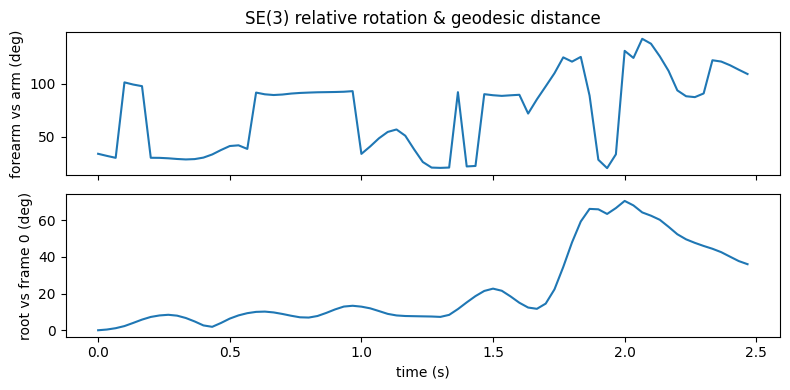

In [7]:
pos = bvh.node_positions()
def seg(a, b):
    return np.stack([pos[:, bvh.index(a, space="node")],
                     pos[:, bvh.index(b, space="node")]], axis=1)  # (F, 2, 3)

relative = rotations.relative_transform(seg("RightArm", "RightForeArm"),
                                        seg("RightForeArm", "RightHand"))
twist = rotations.se3_log(relative)                 # (F, 6) = [ω, v]
elbow_angle = np.degrees(np.linalg.norm(twist[:, :3], axis=-1))

# how far each frame's root orientation has rotated from the first frame
_, rotmats = bvh.to_rotmat()                         # (F, J, 3, 3)
root_R = rotmats[:, 0]
geo = np.degrees(rotations.rotation_geodesic_distance(
    np.broadcast_to(root_R[0], root_R.shape), root_R))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
a1.plot(t, elbow_angle); a1.set(ylabel="forearm vs arm (deg)")
a2.plot(t, geo); a2.set(ylabel="root vs frame 0 (deg)", xlabel="time (s)")
a1.set_title("SE(3) relative rotation & geodesic distance")
plt.tight_layout()

## Summary

| Module | Descriptor | Bvh method | Returns |
|---|---|---|---|
| `geometry` | `path_length`, `directness`, `curvature`, `torsion`, `ground_path` | yes (single joint) | trajectory shape |
| `geometry` | `inter_joint_distance`, `joint_angle`, `triangle_area`, `bounding_box`, `bounding_sphere`, `center_of_mass`, `verticality` | yes | per-frame geometry |
| `analysis` | `node_jerk`, `smoothness`, `kinetic_energy` | yes | dynamics |
| `analysis` | `cadence`, `stride_length`, `walking_pace`, `range_of_motion` | yes | gait / ROM |
| `rotations` | `se3_exp`/`se3_log`, `screw_interpolate`, `relative_transform`, `rotation_geodesic_distance` | — | SE(3) |

Everything is pure NumPy and vectorized over frames. The array-pure kernels
(`geometry.*`, the smoothness functions, the SE(3) math) take plain arrays, so
a downstream library can call them without a `Bvh` at all.